In [3]:
#importing Libraries
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_private_forModel.xlsx to data_private_forModel.xlsx


In [4]:
# Sau khi tải lên, bạn có thể đọc file Excel như sau:
import pandas as pd
df = pd.read_excel('data_private_forModel.xlsx')
df.head()

,ChamNoi,CungNhac,CoLap,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,PhanUngTenGoi,DiNhonChan,ChiTro,TiepXucMat,TargetBinary
0,0,0,0,0,0.0,0.0,0.0,0,0.5,0.0,1
1,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,1
2,0,0,0,1,0.5,0.0,0.0,0,1.0,0.5,1
3,1,0,0,0,0.5,0.0,0.0,0,1.0,0.0,1
4,0,0,0,0,0.0,0.0,0.0,0,0.0,0.5,1


In [5]:
for i, col in enumerate(df.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: ChamNoi
Vị trí 1: CungNhac
Vị trí 2: CoLap
Vị trí 3: HanhViLapLai
Vị trí 4: KyNangGiaoTiepSom
Vị trí 5: ChoiLuanPhien
Vị trí 6: PhanUngTenGoi
Vị trí 7: DiNhonChan
Vị trí 8: ChiTro
Vị trí 9: TiepXucMat
Vị trí 10: TargetBinary


In [6]:
# Liệt kê tên các cột
print(df.columns.tolist())
rows, cols = df.shape
print(f"Số hàng: {rows}, Số cột: {cols}")

['ChamNoi', 'CungNhac', 'CoLap', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'TiepXucMat', 'TargetBinary']
Số hàng: 864, Số cột: 11


In [7]:
X = df.iloc[:, 0:10]
y = df.iloc[:, 10]

# TRAINING VÀ ĐÁNH GIÁ MODEL

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:43:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


==== Đánh giá mô hình XGBoost (chạy đơn) ====
Accuracy:     0.977
Recall:       0.969
Specificity:  0.987
Precision:    0.990
F1-score:     0.979
ROC AUC:      0.997
G-Mean:       0.978

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: TiepXucMat, Score: 0.77369
Feature: ChamNoi, Score: 0.08690
Feature: PhanUngTenGoi, Score: 0.04746
Feature: HanhViLapLai, Score: 0.02563
Feature: CungNhac, Score: 0.02480
Feature: CoLap, Score: 0.01298
Feature: ChiTro, Score: 0.01155
Feature: KyNangGiaoTiepSom, Score: 0.00990
Feature: DiNhonChan, Score: 0.00708
Feature: ChoiLuanPhien, Score: 0.00000


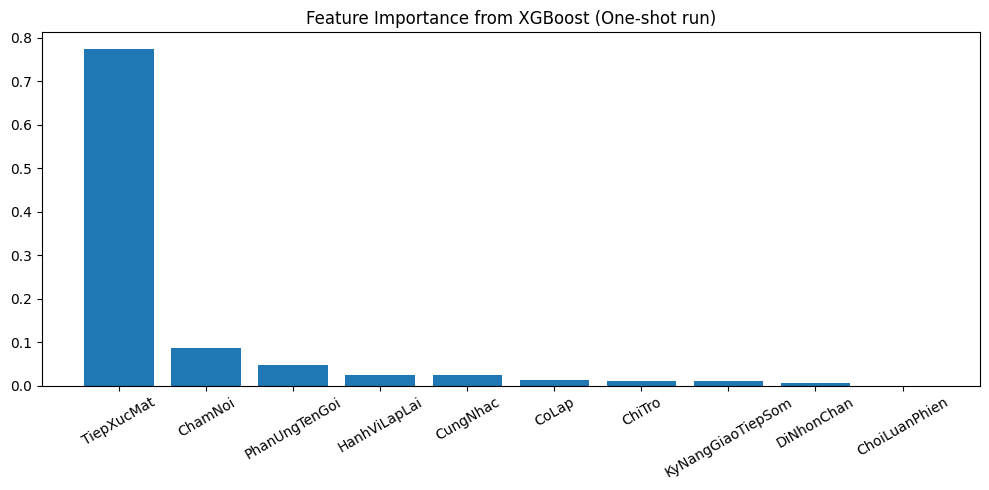

In [9]:
from xgboost import XGBClassifier
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import numpy as np
import pandas as pd

# 1. Chuẩn bị dữ liệu
X = df.drop(columns='TargetBinary')
y = df['TargetBinary']

# 2. Tách train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Tạo pipeline với XGBoost và SimpleImputer
model = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('model', model)
])

# 4. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 5. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Các độ đo cơ bản
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix + các độ đo nâng cao
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0
gmean = np.sqrt(recall * specificity)

# 6. In kết quả
print("==== Đánh giá mô hình XGBoost (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 7. Tầm quan trọng của đặc trưng
importances = pipeline.named_steps['model'].feature_importances_
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 8. Biểu đồ độ quan trọng
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from XGBoost (One-shot run)')
plt.tight_layout()
plt.show()

# Cross-Validation

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
import numpy as np
import pandas as pd

# 2. Thiết lập Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Danh sách lưu độ đo cho từng Fold
results = []

# 4. Lặp qua từng fold
fold = 1
for train_index, test_index in kf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_test_fold)
    y_proba = model.predict_proba(X_test_fold)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test_fold, y_pred).ravel()

    accuracy = accuracy_score(y_test_fold, y_pred)
    recall = recall_score(y_test_fold, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)
    roc_auc = roc_auc_score(y_test_fold, y_proba)
    gmean = np.sqrt(recall * specificity)

    results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Specificity": specificity,
        "Precision": precision,
        "F1-score": f1,
        "ROC AUC": roc_auc,
        "G-Mean": gmean
    })
    fold += 1

# 5. Tạo DataFrame kết quả
results_df = pd.DataFrame(results)

# 6. Thêm dòng Trung bình
mean_row = {
    "Fold": "Trung bình",
    "Accuracy": results_df["Accuracy"].mean(),
    "Recall": results_df["Recall"].mean(),
    "Specificity": results_df["Specificity"].mean(),
    "Precision": results_df["Precision"].mean(),
    "F1-score": results_df["F1-score"].mean(),
    "ROC AUC": results_df["ROC AUC"].mean(),
    "G-Mean": results_df["G-Mean"].mean()
}
results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

# Làm tròn
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(3)

# 7. In kết quả
print("==== Kết quả Cross-Validation cho Decision Tree ====")
print(results_df.to_string(index=False))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


==== Kết quả Cross-Validation cho Decision Tree ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1     0.977   0.969        0.987      0.990     0.979    0.995   0.978
         2     0.983   0.980        0.987      0.990     0.985    0.999   0.983
         3     0.977   0.969        0.987      0.990     0.979    0.988   0.978
         4     0.988   0.990        0.987      0.990     0.990    0.999   0.988
         5     0.959   0.928        1.000      1.000     0.963    0.989   0.963
Trung bình     0.977   0.967        0.989      0.992     0.979    0.994   0.978


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
